        # Evaluación rápida de métricas de clustering

        Usamos los latentes preprocesados (AE/VAE) guardados en `data/autoencoder_trained_v2` y la librería `utils.cluster_metrics` para evaluar calidad interna y estabilidad entre escenarios.
        

In [17]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Configuración de rutas para importar utils
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts" / "idroverdi_autoencoder_3" / "utils").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "scripts" / "idroverdi_autoencoder_3"))

from utils.cluster_metrics import (
    compute_internal_metrics,
    compute_pairwise_label_metrics,
    evaluate_kmeans_grid,
    summarize_scenarios,
)

DATA_DIR = "/home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_trained_v2"
print(f"Usando datos desde: {DATA_DIR}")


        

Usando datos desde: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_trained_v2


In [19]:
# Cargar latentes y labels precalculados (sin depender de pickle)
from pathlib import Path

data_dir_path = Path(DATA_DIR)
ae_npz = np.load(data_dir_path / "ae_latents_test.npz")
vae_npz = np.load(data_dir_path / "vae_latents_test.npz")

ae_latents = {
    "B245": ae_npz["zB245"],
    "B370": ae_npz["zB370"],
    "B585": ae_npz["zB585"],
    "T245": ae_npz["z_245"],
    "T370": ae_npz["z_370"],
    "T585": ae_npz["z_585"],
}
ae_labels = {
    "B245": ae_npz["clB_245"],
    "B370": ae_npz["clB_370"],
    "B585": ae_npz["clB_585"],
    "T245": ae_npz["cl_245"],
    "T370": ae_npz["cl_370"],
    "T585": ae_npz["cl_585"],
}

vae_latents = {
    "B245": vae_npz["mu_B245"],
    "B370": vae_npz["mu_B370"],
    "B585": vae_npz["mu_B585"],
    "T245": vae_npz["mu_245"],
    "T370": vae_npz["mu_370"],
    "T585": vae_npz["mu_585"],
}
vae_labels = {
    "B245": vae_npz["clB_245"],
    "B370": vae_npz["clB_370"],
    "B585": vae_npz["clB_585"],
    "T245": vae_npz["cl_245"],
    "T370": vae_npz["cl_370"],
    "T585": vae_npz["cl_585"],
}

print(f"AE: {list(ae_latents.keys())}")
print(f"VAE: {list(vae_latents.keys())}")
        

AE: ['B245', 'B370', 'B585', 'T245', 'T370', 'T585']
VAE: ['B245', 'B370', 'B585', 'T245', 'T370', 'T585']


In [20]:
def summarize_internal(latents_dict, labels_dict, name):
    summary = summarize_scenarios(latents_dict, labels_dict)
    print(f"Métricas internas — {name}")
    display(summary["internal"][
        ["n_clusters", "silhouette", "davies_bouldin", "calinski_harabasz", "min_cluster_size", "max_cluster_size"]
    ])
    print(f"Estabilidad entre escenarios — {name}")
    display(summary["stability"])

summarize_internal(ae_latents, ae_labels, "AE")
summarize_internal(vae_latents, vae_labels, "VAE")
        

Métricas internas — AE


,n_clusters,silhouette,davies_bouldin,calinski_harabasz,min_cluster_size,max_cluster_size
scenario,,,,,,
B245,2.0,0.360057,1.155450,441.187469,303.0,358.0
B370,2.0,0.367661,1.035378,498.137360,243.0,418.0
B585,2.0,0.455571,0.861412,538.389832,133.0,528.0
T245,3.0,0.141750,0.808523,285.933899,58.0,501.0
T370,3.0,0.057559,0.746824,105.110298,3.0,585.0
T585,3.0,0.257850,0.811426,276.108368,1.0,333.0


Estabilidad entre escenarios — AE


,ari,ami,nmi,fowlkes_mallows,match_ratio
pair,,,,,
B245 vs B370,0.669248,0.637224,0.637633,0.840983,0.000000
B245 vs B585,0.233197,0.314233,0.315107,0.683502,0.000000
B245 vs T245,0.098572,0.254097,0.255719,0.596285,0.608169
B245 vs T370,0.084726,0.178607,0.181290,0.665645,0.647504
B245 vs T585,0.585642,0.483137,0.484475,0.792926,0.077156
B370 vs B585,0.430342,0.428491,0.429240,0.776291,0.201210
B370 vs T245,0.199691,0.301051,0.302608,0.655263,0.000000
B370 vs T370,0.195310,0.237942,0.240497,0.723709,0.000000
B370 vs T585,0.505795,0.479650,0.480991,0.760990,0.001513


Métricas internas — VAE


,n_clusters,silhouette,davies_bouldin,calinski_harabasz,min_cluster_size,max_cluster_size
scenario,,,,,,
B245,3.0,0.417368,0.924171,583.593994,194.0,257.0
B370,5.0,0.401117,0.717379,455.716705,2.0,339.0
B585,4.0,0.377764,0.857384,521.500305,28.0,259.0
T245,4.0,0.378794,0.766114,839.232910,14.0,293.0
T370,3.0,0.298221,0.984879,586.009949,147.0,359.0
T585,3.0,0.144661,0.931982,314.698303,17.0,496.0


Estabilidad entre escenarios — VAE


,ari,ami,nmi,fowlkes_mallows,match_ratio
pair,,,,,
B245 vs B370,0.378404,0.489133,0.491981,0.589615,0.000000
B245 vs B585,0.831386,0.815137,0.815873,0.886808,0.000000
B245 vs T245,0.563853,0.611724,0.613344,0.712722,0.815431
B245 vs T370,0.369155,0.478940,0.480451,0.601707,0.739788
B245 vs T585,0.302953,0.442715,0.444710,0.633597,0.565809
B370 vs B585,0.348514,0.468729,0.472722,0.562617,0.045386
B370 vs T245,0.535187,0.558134,0.561565,0.694995,0.000000
B370 vs T370,0.189939,0.308435,0.312361,0.489684,0.000000
B370 vs T585,0.305143,0.317448,0.321760,0.636579,0.000000


,k,inertia,n_iter,silhouette,davies_bouldin,calinski_harabasz
0,2,6987.810059,13.0,0.360057,1.155450,441.187469
1,3,5399.433594,4.0,0.309473,1.187442,381.836914
2,4,4504.758301,14.0,0.311666,1.248998,348.146057
3,5,3856.807373,8.0,0.301969,1.175970,332.064636
4,6,3341.405273,27.0,0.310910,1.079530,326.366669
5,7,2929.558838,14.0,0.313168,1.093438,325.056915
6,8,2683.115234,34.0,0.306410,1.066953,312.314545


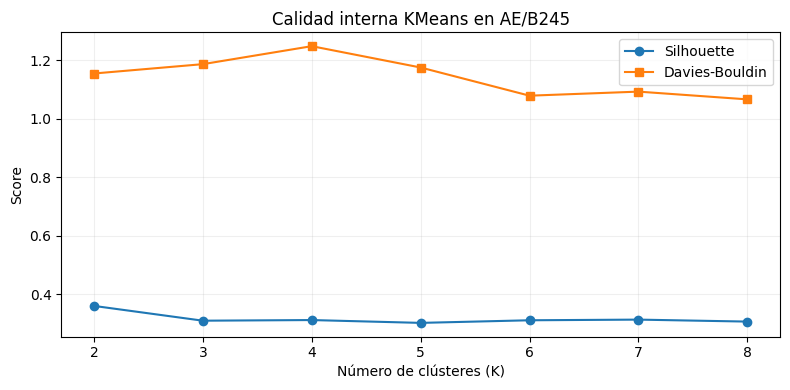

In [21]:
# Búsqueda rápida de K en AE/B245
k_grid = range(2, 9)
k_results = evaluate_kmeans_grid(
    ae_latents["B245"],
    k_values=k_grid,
    random_state=42,
    n_init=20,
    sample_size=None,
)
display(k_results)

plt.figure(figsize=(8, 4))
plt.plot(k_results["k"], k_results["silhouette"], marker="o", label="Silhouette")
plt.plot(k_results["k"], k_results["davies_bouldin"], marker="s", label="Davies-Bouldin")
plt.xlabel("Número de clústeres (K)")
plt.ylabel("Score")
plt.title("Calidad interna KMeans en AE/B245")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
        